### [Stock Market Signal Analysis](https://medium.com/@nidhi.patel23/stock-market-signal-analysis-using-fft-the-role-of-dsp-in-finance-a016c799e567)

> *DSP (Digital Signal Processing) is about analyzing signals in the time and frequency domains. In finance, however, the "signal" is the time series of stock prices, returns, or trading volumes.*

#### Stock Market Signal Analysis Using FFT

In [1]:
!pip install --quiet yfinance

In [2]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Download last 60 days of AAPL stock data
data = yf.download("AAPL", period="60d", progress=False, auto_adjust=True)
prices = data['Close'].values
t = np.arange(len(prices))

# Select last 30 days for analysis
prices_30 = prices[-30:]
t_30 = t[-30:]

display(data.sample(10))

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-10-17,252.045654,253.134610,247.030527,247.779801,49147000
2025-11-19,268.559998,272.209991,265.500000,265.529999,40424500
2025-12-01,283.100006,283.420013,276.140015,278.010010,46587700
2025-10-28,268.739471,269.628624,267.890289,268.729471,41534800
2025-10-31,270.108154,277.051436,268.899335,276.721738,86167100
2025-12-08,277.890015,279.670013,276.149994,278.130005,38211800
2025-11-11,275.250000,275.910004,269.799988,269.809998,46208300
2025-12-02,286.190002,287.399994,282.630005,283.000000,53669500


#### Visualizing the Original Prices

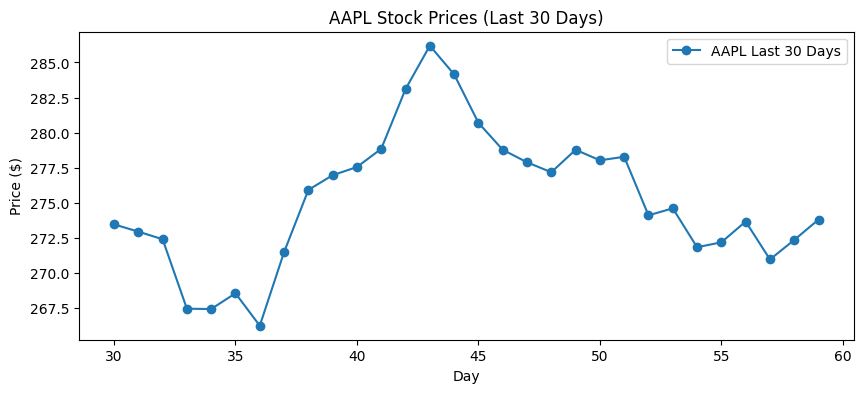

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(t_30, prices_30, marker='o', label="AAPL Last 30 Days")
plt.title("AAPL Stock Prices (Last 30 Days)")
plt.xlabel("Day")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

#### Applying FFT to Detect Cycles

In [4]:
# Apply FFT
fft_vals = np.fft.fft(prices_30)
fft_freq = np.fft.fftfreq(len(prices_30), d=1)

# Only positive frequencies
pos_mask = fft_freq > 0
fft_vals = fft_vals[pos_mask]
fft_freq = fft_freq[pos_mask]

display(fft_vals)

display(fft_freq)

array([[272.95001221+0.j],
       [272.41000366+0.j],
       [267.45999146+0.j],
       [267.44000244+0.j],
       [268.55999756+0.j],
       [266.25      +0.j],
       [271.48999023+0.j],
       [275.92001343+0.j],
       [276.97000122+0.j],
       [277.54998779+0.j],
       [278.8500061 +0.j],
       [283.1000061 +0.j],
       [286.19000244+0.j],
       [284.1499939 +0.j]])

array([0.03333333, 0.06666667, 0.1       , 0.13333333, 0.16666667,
       0.2       , 0.23333333, 0.26666667, 0.3       , 0.33333333,
       0.36666667, 0.4       , 0.43333333, 0.46666667])

#### Visualizing the Frequency Spectrum

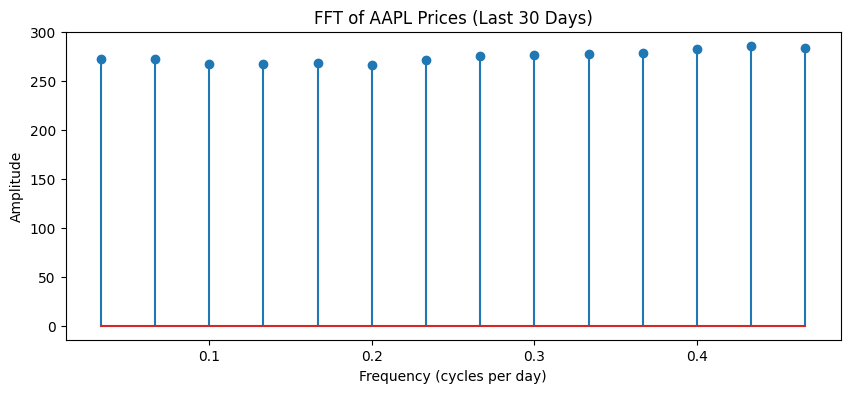

In [5]:
plt.figure(figsize=(10, 4))
plt.stem(fft_freq, np.abs(fft_vals))
plt.title("FFT of AAPL Prices (Last 30 Days)")
plt.xlabel("Frequency (cycles per day)")
plt.ylabel("Amplitude")
plt.show()

#### Detecting Dominant Cycles

In [6]:
dominant_freqs = fft_freq[np.argsort(np.abs(fft_vals))[-3:]]
dominant_periods = 1 / dominant_freqs
print("Top 3 dominant cycles (in days):", dominant_periods)

Top 3 dominant cycles (in days): [[30.]
 [30.]
 [30.]]


#### Reconstructing a Smoothed Signal (Optional)

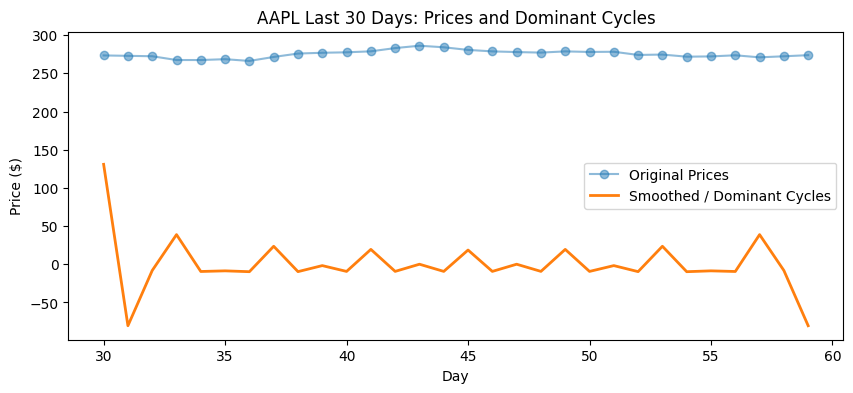

In [7]:
threshold = np.abs(fft_vals).mean()  # keep strong frequencies
fft_filtered = fft_vals * (np.abs(fft_vals) > threshold)
fft_filt_len = len(fft_filtered)

# Mirror for negative frequencies to reconstruct full FFT
full_fft = np.zeros(len(prices_30), dtype=complex)
full_fft[1:fft_filt_len + 1] = fft_filtered.flatten()
full_fft[-fft_filt_len:] = np.conj(fft_filtered[::-1]).flatten()

# Inverse FFT to get smoothed prices
smoothed_prices = np.fft.ifft(full_fft).real

plt.figure(figsize=(10, 4))
plt.plot(t_30, prices_30, marker='o', alpha=0.5, label="Original Prices")
plt.plot(t_30, smoothed_prices, linewidth=2, label="Smoothed / Dominant Cycles")
plt.title("AAPL Last 30 Days: Prices and Dominant Cycles")
plt.xlabel("Day")
plt.ylabel("Price ($)")
plt.legend()
plt.show()